### IID Uniform Sampling for Linear Region Count

#### Imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

#### Generate iid uniform random sample:

In [2]:
def iid_uniform_sample(num_points,dimensions, lower_bounds, upper_bounds, rng):
    """Generates an iid uniform sample of points in a space of some dimension
    Args:
        num_points: the number of points to sample
        dimensions: the dimension of the space to sample from
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        rng: a random number generator used to ensure reproducibility of the sample
    Returns:
        points: 2D array of shape (num_points,dimensions) representing all the points
    """

    points = np.zeros((num_points,dimensions))
    for d in range(dimensions):
        sample = rng.uniform(lower_bounds[d],upper_bounds[d],num_points)
        points[:,d] = sample
    return points

In [3]:
num_points = 10000
dimensions = 2
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
rng = np.random.default_rng(seed=1)
points = iid_uniform_sample(num_points,dimensions,lower_bounds,upper_bounds,rng)

Display sample:

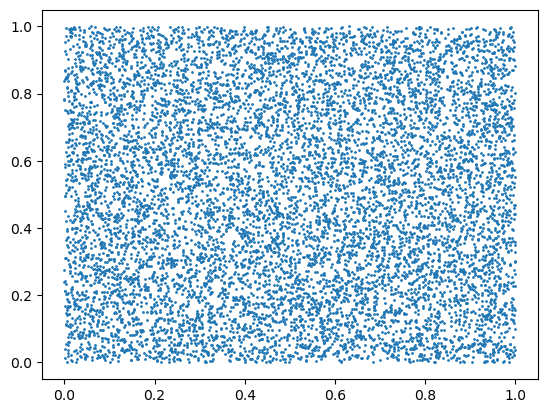

In [4]:
plt.scatter(points[:,0],points[:,1],s=1)

#### Set up MLP

Create class for MLP with 1 hidden layer and 20 hidden neurons. Sample initial weights randomly from Kaiming normal distribution:

In [11]:
class simple_MLP(torch.nn.Module):
    def __init__(self, dimensions,neurons):
        super().__init__()
        self.linear1 = torch.nn.Linear(dimensions,neurons,bias=False)
        self.relu1 = torch.nn.ReLU()
        generator = torch.Generator()
        generator.manual_seed(1)
        #self.apply(lambda m: self.init_weights(m, generator))
        custom_weights = torch.tensor([
            [1.0,-1.0],
            [1.0,1.0]
        ])
        with torch.no_grad():
            self.linear1.weight.copy_(custom_weights)

    def init_weights(self, module, generator):
        if isinstance(module, torch.nn.Linear):
            # Use Kaiming normal distribution to initialise weights
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity="relu",generator=generator)

    def forward(self,x):
        logits = self.relu1(self.linear1(x))
        return logits

Function to get activations from each layer:

In [57]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        values = output.detach()
        activation_pattern = ""
        for value in values[0]:
            if value > 0:
                activation_pattern += "1"
            else:
                activation_pattern += "0"
        activations[name] = activation_pattern
    return hook

In [51]:
model = simple_MLP(dimensions=2,neurons=2)
model.linear1.register_forward_hook(get_activation("linear1"))

In [15]:
print(model.linear1.weight)

Parameter containing:
tensor([[ 1., -1.],
        [ 1.,  1.]], requires_grad=True)


Test with example input:

In [52]:
input_tensor = torch.tensor([0.5,0.6])
output = model(input_tensor)
print(output)

tensor(-0.1000)
tensor(1.1000)
tensor([0.0000, 1.1000], grad_fn=<ReluBackward0>)


In [53]:
print(activations)

{'linear1': '01'}


Create PyTorch Datasets and Data Loaders to sequentially pass input samples into the network (in batches of size 20):

In [22]:
class SampleDataset(torch.utils.data.Dataset):
    """Custom dataset designed to store samples to be used in linear region counting"""

    def __init__(self, points):
        # self.points = array of samples of shape (num_points,input dimension)
        self.points = points
        
    def __len__(self):
        return points.shape[0]

    def __getitem__(self,index):
        input = points[index,:]
        return input

In [23]:
num_points = 10000
dimensions = 2
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
rng = np.random.default_rng(seed=1)

points = iid_uniform_sample(num_points,dimensions,lower_bounds,upper_bounds,rng)
sample_dataset = SampleDataset(points)
sample_data_loader = torch.utils.data.DataLoader(sample_dataset, batch_size=20, shuffle=False)

In [24]:
inputs = next(iter(sample_data_loader))
print(inputs)

tensor([[0.5118, 0.5721],
        [0.9505, 0.0313],
        [0.1442, 0.1453],
        [0.9486, 0.8244],
        [0.3118, 0.3381],
        [0.4233, 0.6849],
        [0.8277, 0.3374],
        [0.4092, 0.0755],
        [0.5496, 0.1661],
        [0.0276, 0.0270],
        [0.7535, 0.3848],
        [0.5381, 0.1961],
        [0.3297, 0.7869],
        [0.7884, 0.0534],
        [0.3032, 0.7151],
        [0.4535, 0.6714],
        [0.1340, 0.4915],
        [0.4031, 0.4720],
        [0.2035, 0.1811],
        [0.2623, 0.3293]], dtype=torch.float64)


#### Code to count activation patterns/linear regions:

Function to get numbers of unique linear regions after $N$ samples, $U(N)$:

In [60]:
def region_count(sample_data_loader,model):
    """Count the number of unique linear regions in the input space of a MLP using
    random sample of points from that input space"""

    # Store unique activation patterns in a set for constant lookup time
    all_patterns = set()
    unique_counts = []

    # IMPORTANT: ONLY WORKS FEEDING INPUTS IN ONE AT A TIME
    for inputs in sample_data_loader:

        inputs = inputs.float()
        outputs = model(inputs)
        activation_pattern = ""
        for layer in activations:
            # String activations from each layer together
            activation_pattern += activations[layer]
        if activation_pattern in all_patterns:
            # If activation pattern has already been seen, keep region count the same
            unique_counts.append(unique_counts[-1])
        else:
            if len(all_patterns)==0:
                unique_counts.append(1)
            else:
                unique_counts.append(unique_counts[-1] + 1)
            all_patterns.add(activation_pattern)

    return unique_counts,all_patterns

In [61]:
num_points = 10000
dimensions = 2
neurons = 2
lower_bounds = np.full(dimensions,-1)
upper_bounds = np.full(dimensions,1)
rng = np.random.default_rng(seed=1)

model = simple_MLP(dimensions,neurons)
model.linear1.register_forward_hook(get_activation("linear1"))
points = iid_uniform_sample(num_points,dimensions,lower_bounds,upper_bounds,rng)
sample_dataset = SampleDataset(points)
sample_data_loader = torch.utils.data.DataLoader(sample_dataset, batch_size=1, shuffle=False)
unique_counts, all_patterns = region_count(sample_data_loader,model)

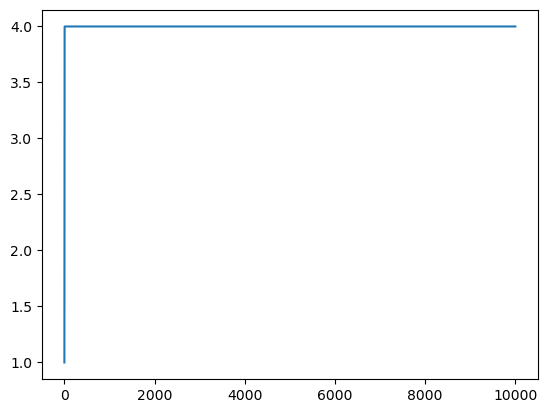

In [62]:
x = np.arange(1,len(unique_counts)+1)
plt.plot(x,unique_counts)